In [1]:
# Thanks to Andy Jones
# https://andrewcharlesjones.github.io/journal/natural-gradients.html

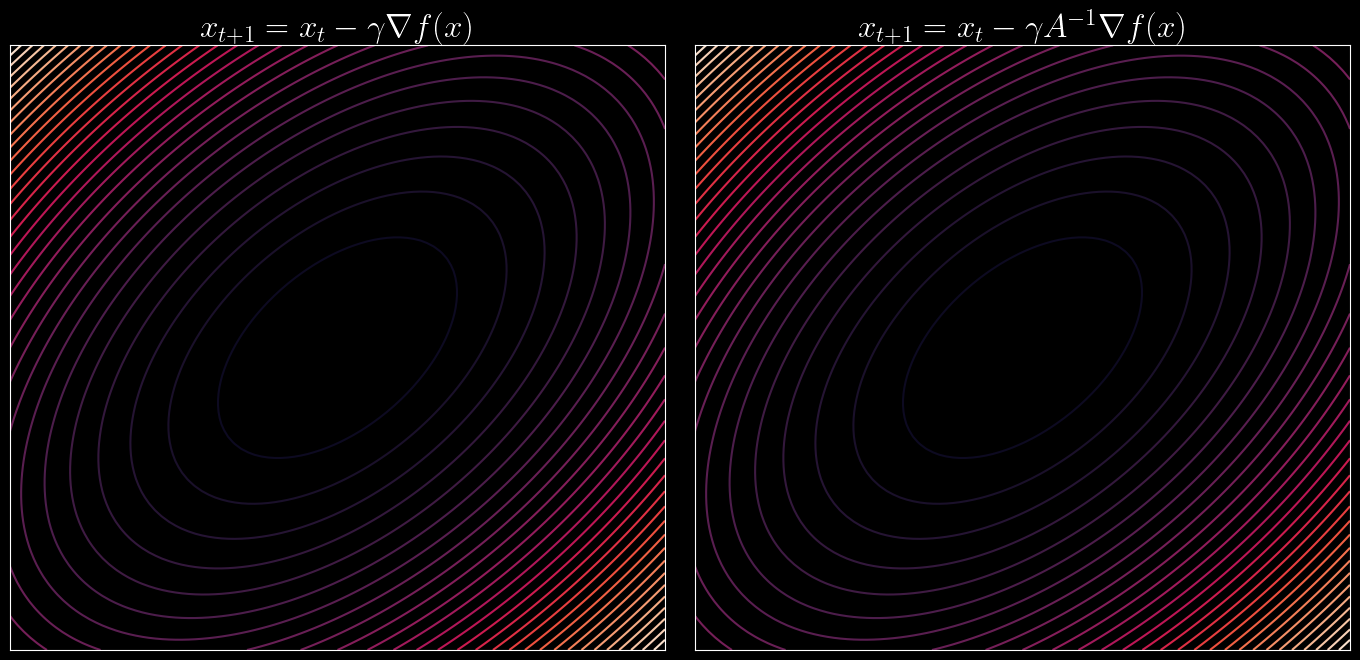

In [5]:
# Code for the steepest descent example using the Mahalanobis metric:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Ellipse
from os.path import join as pjoin
inv = np.linalg.inv
import matplotlib
font = {"size": 30}
matplotlib.rc("font", **font)
matplotlib.rcParams["text.usetex"] = True

A = np.array(
        [[1, -0.5],
        [-0.5, 1]]
)

f = lambda x1, x2: x1**2 + x2**2 - 1 * x1 * x2
fgrad = lambda x1, x2: np.array([2 * x1 - x2, 2*x2 - x1])


plt.figure(figsize=(14, 7))

plt.subplot(121)
xlimits = [-10, 10]
ylimits = [-10, 10]
numticks = 100

x = np.linspace(*xlimits, num=numticks)
y = np.linspace(*ylimits, num=numticks)
X, Y = np.meshgrid(x, y)
zs = f(np.atleast_2d(X.ravel()), np.atleast_2d(Y.ravel()))
Z = zs.reshape(X.shape)
plt.contour(X, Y, Z, levels=30)

xhat = np.array([8., 3.])

for _ in range(10):
        g = -0.5 * fgrad(*xhat)
        plt.arrow(*xhat, *g, head_width=0.5, color="black")
        xhat += g

plt.title(r"$x_{t+1} = x_t - \gamma \nabla f(x)$")
plt.xticks([])
plt.yticks([])


plt.subplot(122)
xlimits = [-10, 10]
ylimits = [-10, 10]
numticks = 100
x = np.linspace(*xlimits, num=numticks)
y = np.linspace(*ylimits, num=numticks)
X, Y = np.meshgrid(x, y)
zs = f(np.atleast_2d(X.ravel()), np.atleast_2d(Y.ravel()))
Z = zs.reshape(X.shape)
plt.contour(X, Y, Z, levels=30)

xhat = np.array([8., 3.])

for _ in range(10):
        g = -0.3 * inv(A) @ fgrad(*xhat)
        plt.arrow(*xhat, *g, head_width=0.5, color="black")
        xhat += g

plt.title(r"$x_{t+1} = x_t - \gamma A^{-1} \nabla f(x)$")
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()

/var/folders/r6/rw7bxdds6z97wk9wbygm02k00000gn/T/ipykernel_13963/191836087.py:20: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  plt.subplot(122)


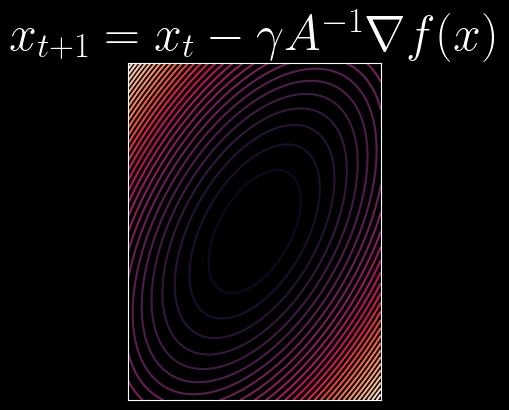

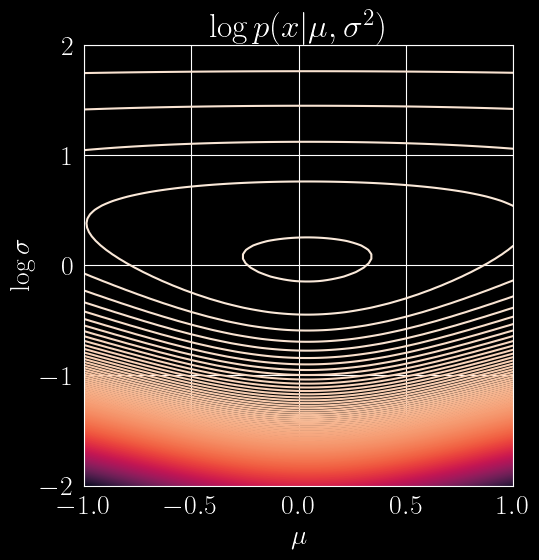

In [4]:
# Code for plotting the Gaussian isocontours:

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import Ellipse
from os.path import join as pjoin
from scipy.stats import norm
inv = np.linalg.inv
import matplotlib
font = {"size": 20}
matplotlib.rc("font", **font)
matplotlib.rcParams["text.usetex"] = True


mu_true = 0
sigma2_true = 1
n = 2000
data = np.random.normal(mu_true, np.sqrt(sigma2_true), size=n)

f = lambda mu, lam: n * (-0.5 * np.log(2 * np.pi) - lam) - 0.5 * np.exp(-2 * lam) * (np.sum(data**2) - 2 * mu * np.sum(data) + n * mu**2)

def fgrad(mu, lam):
        mugrad = -0.5 * np.exp(-2 * lam) * (2 * mu * np.sum(data) + n * mu)
        lamgrad = n + np.exp(-2 * lam) * (np.sum(data**2) - 2 * mu * np.sum(data) + n * mu**2)
        return np.array([mugrad, lamgrad])

plt.figure(figsize=(6, 6))
xlimits = [-1, 1]
ylimits = [-2, 2]
numticks = 100
x = np.linspace(*xlimits, num=numticks)
y = np.linspace(*ylimits, num=numticks)
X, Y = np.meshgrid(x, y)
zs = f(np.atleast_2d(X.ravel()), np.atleast_2d(Y.ravel()))
Z = zs.reshape(X.shape)
plt.contour(X, Y, Z, levels=200)
plt.tight_layout()
plt.title(r"$\log p(x | \mu, \sigma^2)$")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\log \sigma$")
plt.xticks(size=20)
plt.yticks(size=20)
plt.tight_layout()
plt.show()